# Meridional Overturning Circulation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%%capture 
# comment above line to see details about the run(s) displayed
from misc import *
from  mom6_tools import m6plot, m6toolbox
from mom6_tools.moc import  *
import glob
from IPython.display import Image, display
%matplotlib inline

In [ ]:
# papermill parameters. Override e.g. with:
#   papermill moc.ipynb moc.ipynb -p basin_from_file /path/to/basin.nc
basin_from_file = None  # path to a precomputed basin-mask file, or None to compute from the grid


In [3]:
ds = []
for c, l, p in zip(casename,label, ocn_path):
  dummy = xr.open_dataset(p+'{}_MOC.nc'.format(c))
  ds.append(dummy) 

### Global MOC

In [4]:
pnum = len(ds)
varName = 'vmo'
Zmod = []
fname ='*.mom6.h.z.*.nc'
for i in range(pnum):
  # this hack needs to be fixed
  print(OUTDIR[i]+fname)
  file = sorted(glob.glob(OUTDIR[i]+fname))[0:2]
  ds1 = xr.open_mfdataset(file)
  Zmod.append(m6toolbox.get_z(ds1, depth[i], varName))

/glade/derecho/scratch/hannay/archive/b.e30_beta08_dev_ncar.B1850C_MTso.ne30_t232_wgx3.337/ocn/hist/*.mom6.h.z.*.nc


#### z

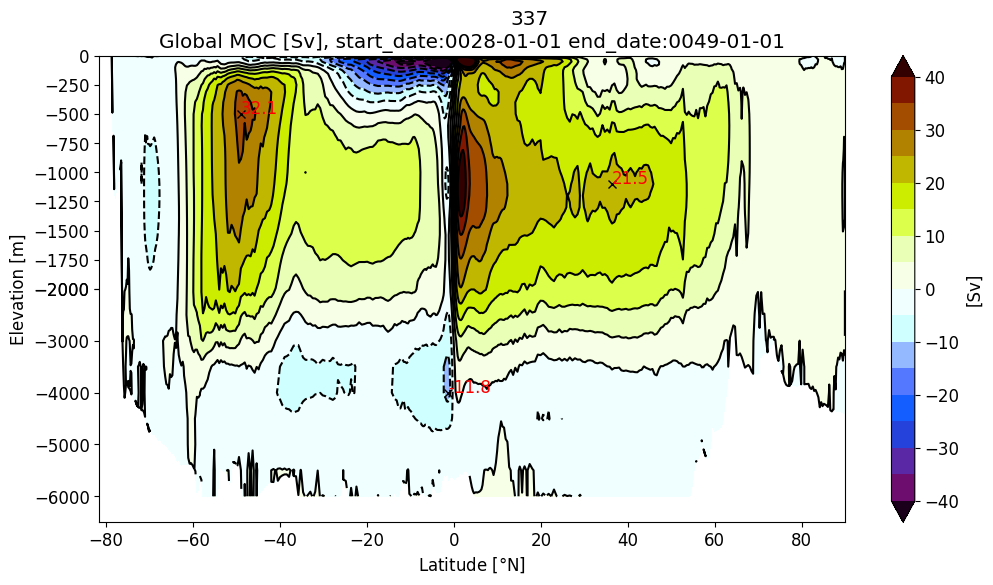

In [5]:
for i in range(pnum):
  m6plot.setFigureSize([16,9],576,debug=False)
  axis = plt.gca()
  cmap = plt.get_cmap('dunnePM')
  zg = Zmod[i].min(axis=-1); 
  psiPlot = ds[i].moc.values
  yyg = grd[i].geolat_c[:,:].max(axis=-1)+0*zg

  ci=m6plot.pmCI(0.,40.,5.)
  plotPsi(yyg, zg, psiPlot, ci, 'Global MOC [Sv], ' + \
         'start_date:' + ds[i].start_date +' end_date:' + ds[i].end_date)
  plt.xlabel(r'Latitude [$\degree$N]')
  plt.suptitle(label[i])

  findExtrema(yyg, zg, psiPlot, max_lat=-30.)
  findExtrema(yyg, zg, psiPlot, min_lat=25., min_depth=250.)
  findExtrema(yyg, zg, psiPlot, min_depth=2000., mult=-1.)
  plt.gca().invert_yaxis()


#### sigma2

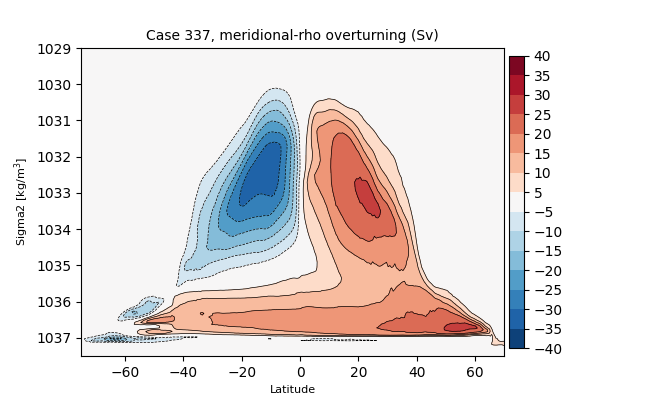

In [6]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_sigma2_global.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### zrho

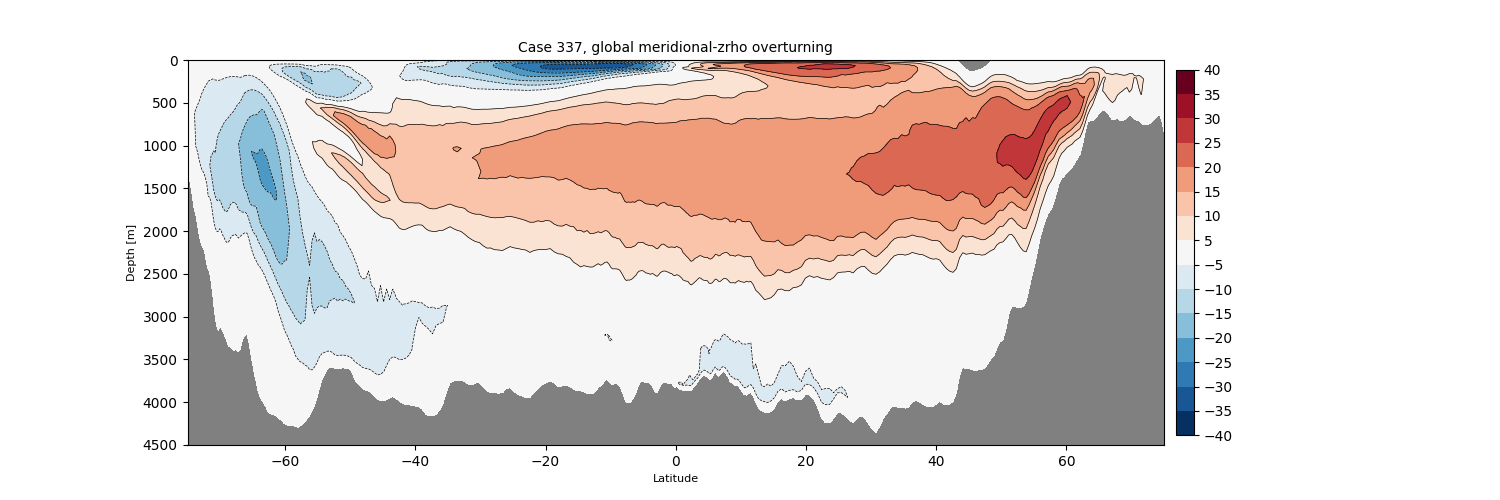

In [7]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_zrho_global.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### Time series 35 S

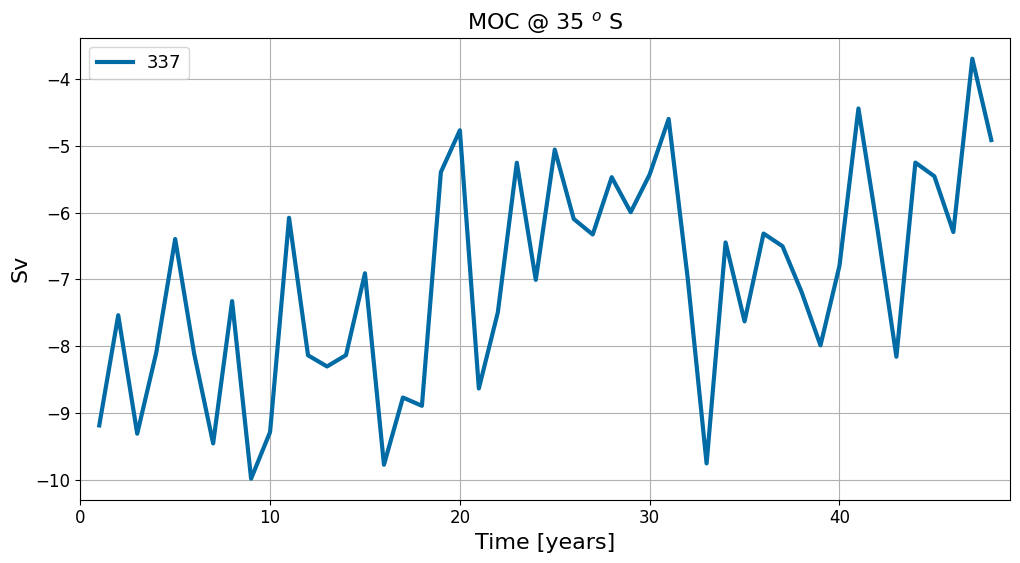

In [8]:
fig = plt.figure(figsize=(12, 6))
for i in range(pnum):
  plt.plot(np.arange(len(ds[i].time))+1 ,ds[i]['moc_35S'].values, 
           label=label[i], lw=3)
plt.title('MOC @ 35 $^o$ S', fontsize=16)
#plt.ylim(10,30)
plt.xlim(0,1+len(ds[0].time))
plt.xlabel('Time [years]', fontsize=16); plt.ylabel('Sv', fontsize=16)
plt.legend(fontsize=13, ncol=2);
plt.grid()

#### Time series 70 S

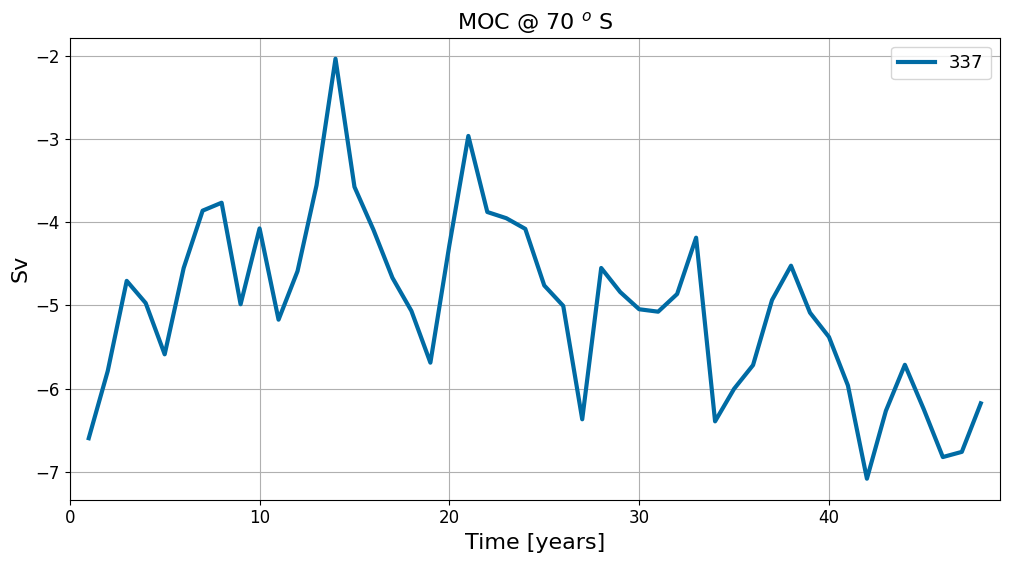

In [9]:
fig = plt.figure(figsize=(12, 6))
for i in range(pnum):
  plt.plot(np.arange(len(ds[i].time))+1 ,ds[i]['moc_70S'].values, 
           label=label[i], lw=3)
plt.title('MOC @ 70 $^o$ S', fontsize=16)
#plt.ylim(10,30)
plt.xlim(0,1+len(ds[0].time))
plt.xlabel('Time [years]', fontsize=16); plt.ylabel('Sv', fontsize=16)
plt.legend(fontsize=13, ncol=2);
plt.grid()

### Atlantic MOC
#### z

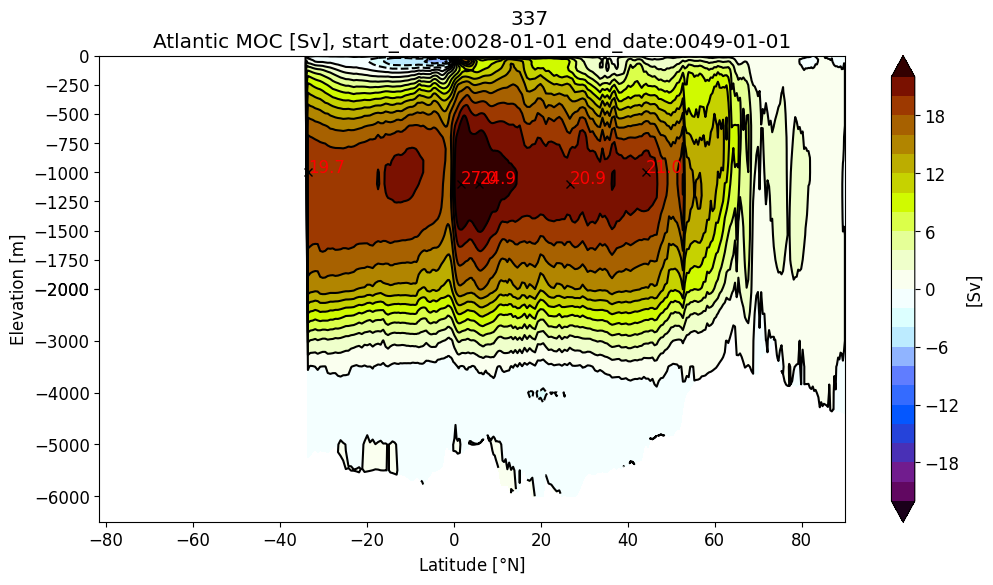

In [ ]:
# 2 - Atlantic; 4 - Arctic; 6 - Med; 7 - Black Sea; 8 - Hudson Bay;
try:
  tmp = findExtrema(yy, z, psiPlot, min_lat=26.5, max_lat=27., min_depth=250., plot=False) # RAPID
  min_lat_rapid = 26.5
  max_lat_rapid = 27.
  max_lat = -33.
except: # for low-res configurations
  min_lat_rapid = 26.
  max_lat_rapid = 28.
  max_lat = -30.

atlantic_regions = ['AtlanticOcean', 'Arctic', 'MedSea', 'BlackSea', 'HudsonBay']
for i in range(pnum):
  basin_code = genBasinMasks(grd[i].geolon, grd[i].geolat, depth[i], xda=True,
                              basin_from_file=basin_from_file)
  m6plot.setFigureSize([16,9],576,debug=False)
  cmap = plt.get_cmap('dunnePM')
  ci=m6plot.pmCI(0.,22.,2.)
  m = basin_code.sel(region=atlantic_regions).sum('region').values
  z = (m*Zmod[i]).min(axis=-1)
  psiPlot = ds[i].amoc.values
  yy = grd[i].geolat_c[:,:].max(axis=-1)+0*z
  plotPsi(yy, z, psiPlot, ci, 'Atlantic MOC [Sv], ' + \
         'start_date:' + ds[i].start_date +' end_date:' + ds[i].end_date)
  plt.xlabel(r'Latitude [$\degree$N]')
  plt.suptitle(label[i])
  findExtrema(yy, z, psiPlot, min_lat=min_lat_rapid, max_lat=max_lat_rapid, min_depth=250.) # RAPID
  findExtrema(yy, z, psiPlot, min_lat=44, max_lat=46., min_depth=250.) # RAPID
  findExtrema(yy, z, psiPlot, max_lat=max_lat)
  findExtrema(yy, z, psiPlot)
  findExtrema(yy, z, psiPlot, min_lat=5.)
  plt.gca().invert_yaxis()

#### sigma2

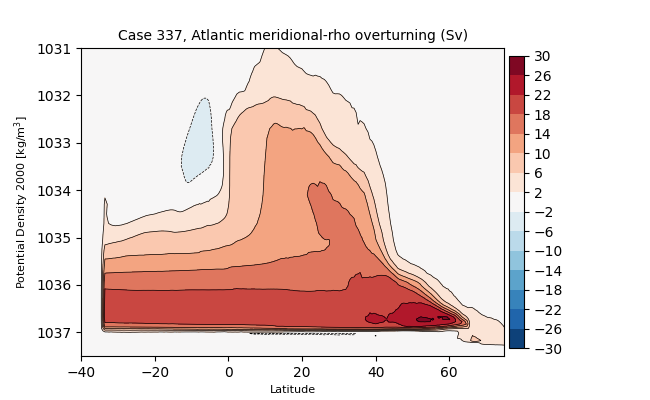

In [11]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_sigma2_Atlantic.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### zrho

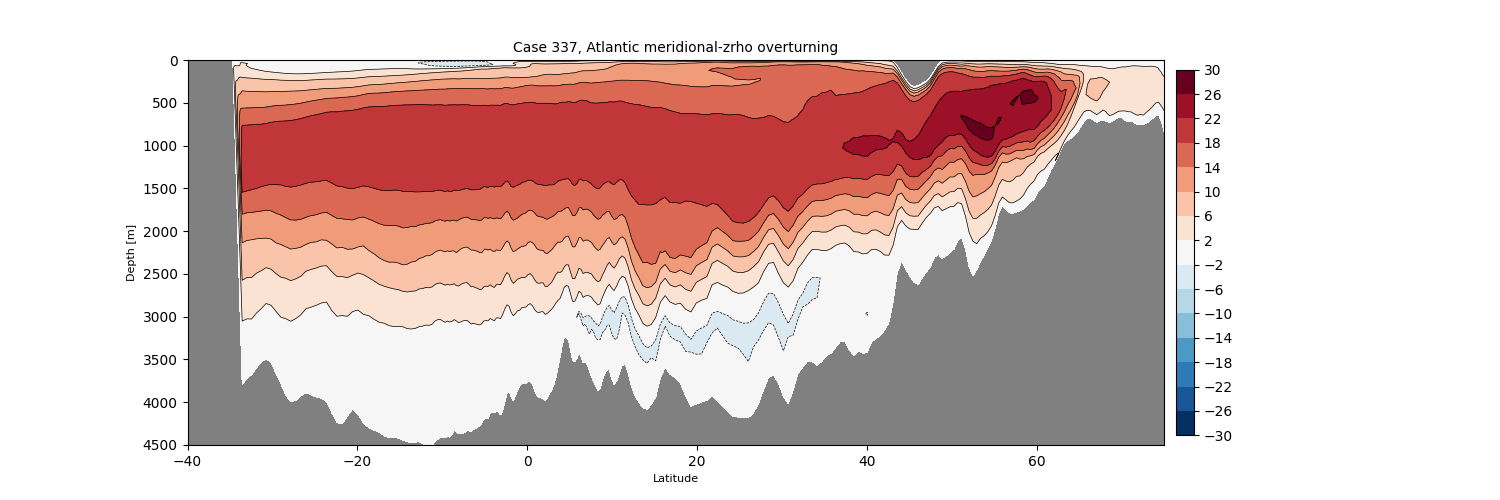

In [12]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_zrho_Atlantic.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### AMOC profile at 26N

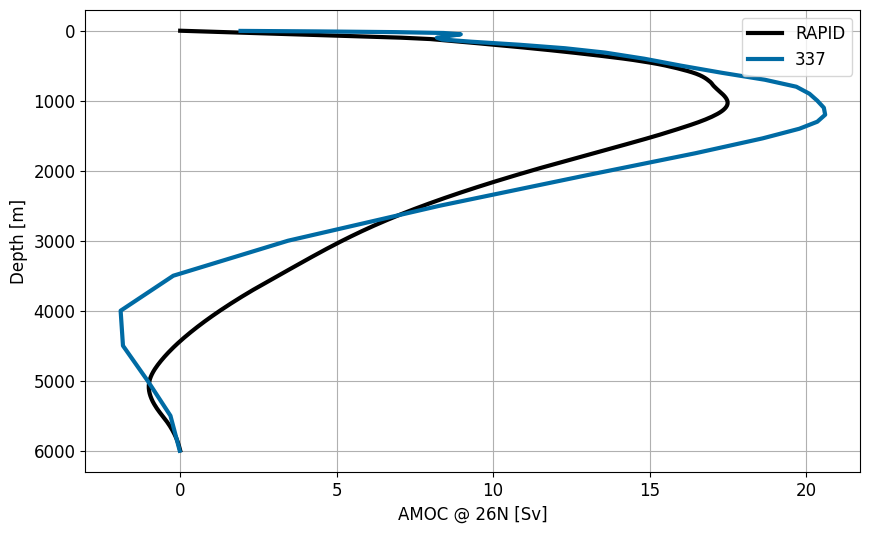

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
rapid_vertical = xr.open_dataset('/glade/work/gmarques/cesm/datasets/RAPID/moc_vertical.nc')
ax.plot(rapid_vertical.stream_function_mar.mean('time'),
        rapid_vertical.depth, 'k', label='RAPID', lw=3)
for i in range(pnum):
  ax.plot(ds[i]['amoc'].sel(yq=26, method='nearest'), ds[i].zl, label=label[i], lw=3)

ax.legend()
plt.gca().invert_yaxis()
plt.grid()
ax.set_xlabel('AMOC @ 26N [Sv]')
ax.set_ylabel('Depth [m]');

#### AMOC time series

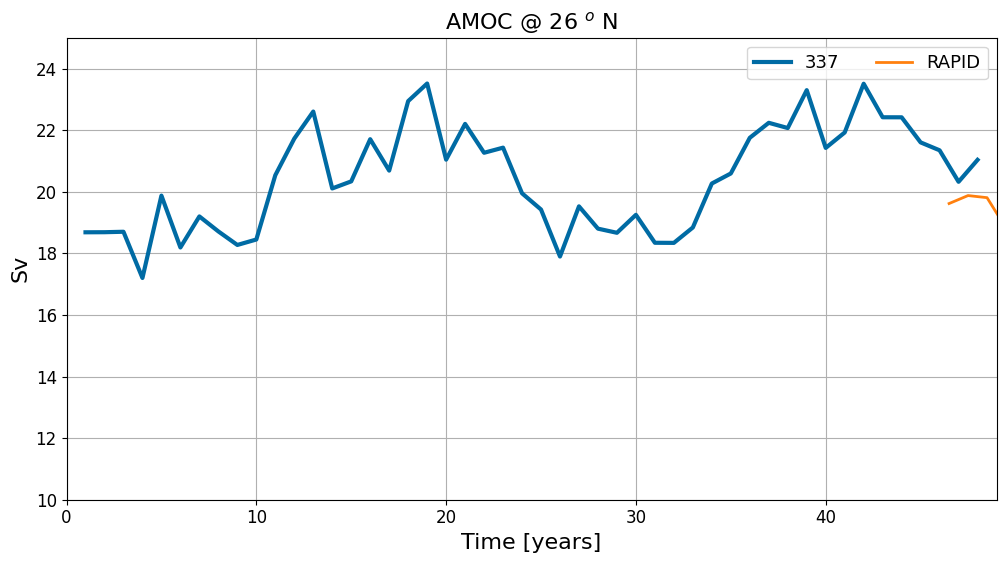

In [14]:
# load RAPID time series
rapid = m6toolbox.weighted_temporal_mean_vars(xr.open_dataset('/glade/work/gmarques/cesm/datasets/RAPID/moc_transports.nc'))

# plot
fig = plt.figure(figsize=(12, 6))
for i in range(pnum):
  plt.plot(np.arange(len(ds[i].time))+1. ,ds[i]['amoc_26'].values, 
           label=label[i], lw=3)
# rapid
plt.plot(np.arange(len(rapid.time))+46.5 ,rapid.moc_mar_hc10.values, 
         label='RAPID', lw=2)

plt.title('AMOC @ 26 $^o$ N', fontsize=16)
plt.ylim(10,25)
plt.xlim(0,1+len(ds[0].time))
plt.xlabel('Time [years]', fontsize=16); plt.ylabel('Sv', fontsize=16)
plt.legend(fontsize=13, ncol=2)
plt.grid()

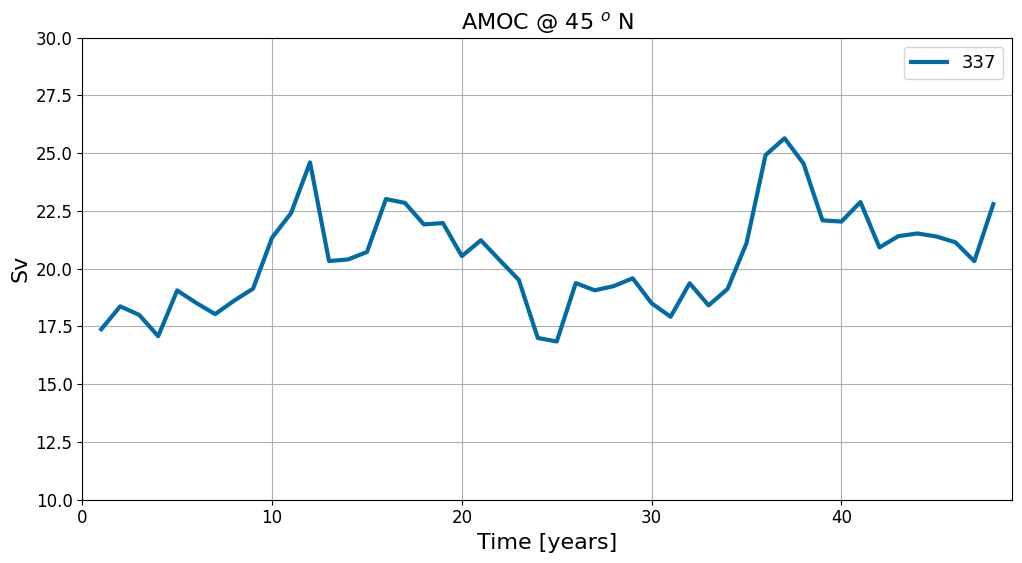

In [15]:
# plot
fig = plt.figure(figsize=(12, 6))
for i in range(pnum):
  plt.plot(np.arange(len(ds[i].time))+1 ,ds[i]['amoc_45'].values, 
           label=label[i], lw=3)
plt.title('AMOC @ 45 $^o$ N', fontsize=16)
plt.ylim(10,30)
plt.xlim(0,1+len(ds[0].time))
plt.xlabel('Time [years]', fontsize=16); plt.ylabel('Sv', fontsize=16)
plt.legend(fontsize=13, ncol=2);
plt.grid()

### Indo-Pacific
#### z

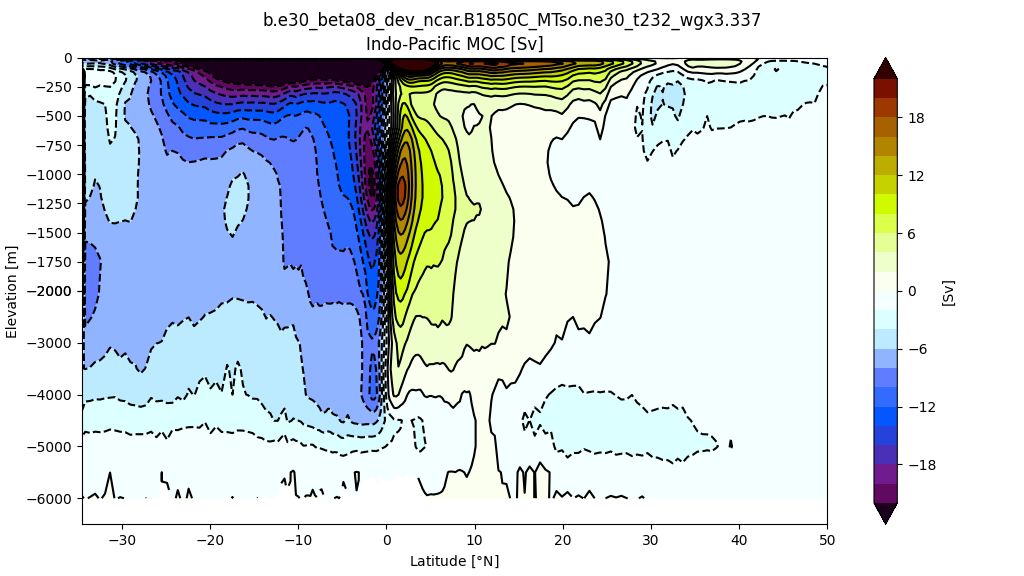

In [16]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_IndoPacific.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### sigma2

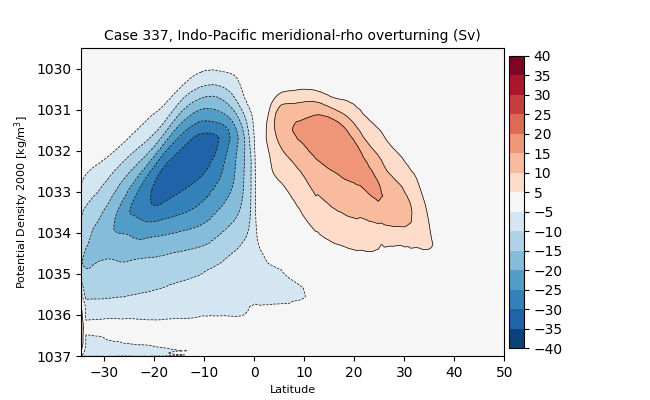

In [17]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_sigma2_IndoPacific.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### zrho

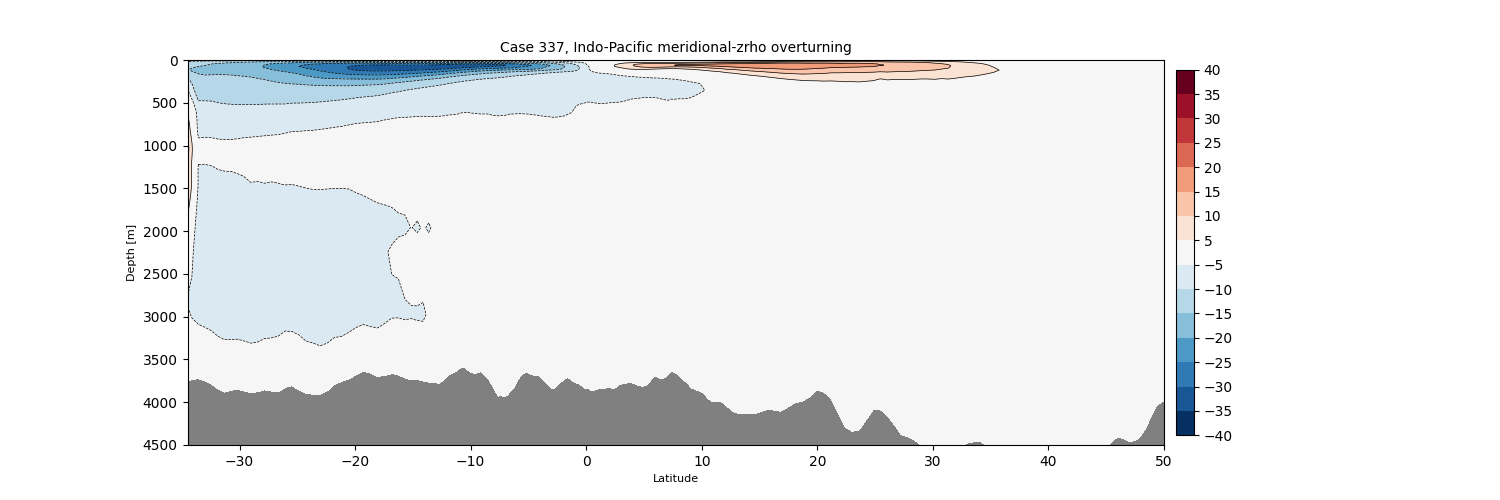

In [18]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_zrho_IndoPacific.png')
  for png_file in png_files:
      display(Image(filename=png_file))

### Submesoscale-induced Global MOC
#### z

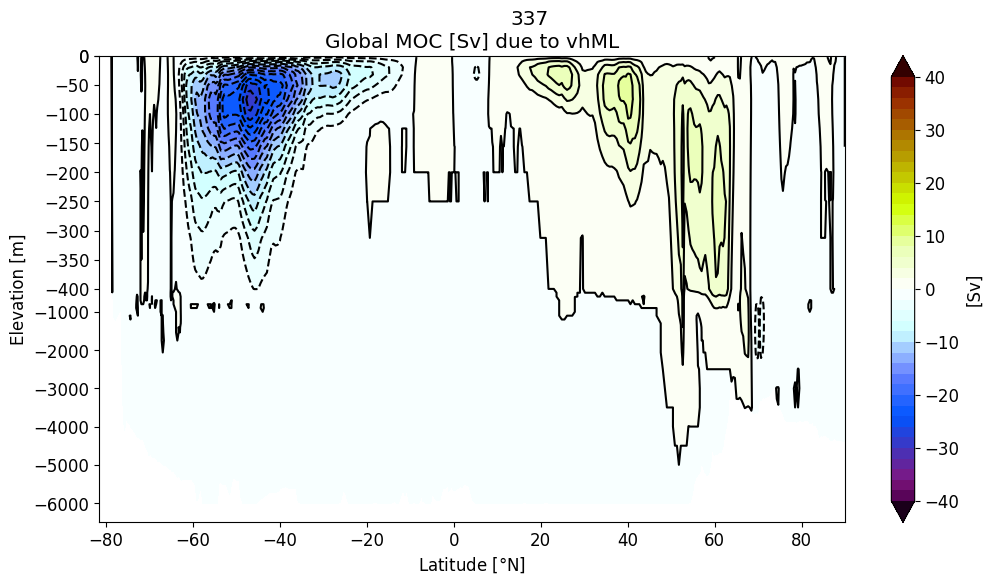

In [19]:
for i in range(pnum):
    # create a ndarray subclass
    class C(np.ndarray): pass
    varName = 'moc_FFH'

    psiPlot = np.ma.masked_invalid(ds[i][varName].values)
    tmp = psiPlot[:].filled(0.)
    VHmod = tmp.view(C)
    VHmod.units = 'Sv'

    # Global MOC
    m6plot.setFigureSize([16,9],576,debug=False)
    axis = plt.gca()
    cmap = plt.get_cmap('dunnePM')
    z =  Zmod[i].min(axis=-1) 
    #yy = y[1:,:].max(axis=-1)+0*z
    yy = grd[i].geolat_c[:,:].max(axis=-1)+0*z
    ci=m6plot.pmCI(0.,40.,2.)
    plotPsi(yy, z, psiPlot, ci, 'Global MOC [Sv] due to vhML', zval=[0.,-400.,-6500.])
    plt.xlabel(r'Latitude [$\degree$N]')
    plt.suptitle(label[i])
    plt.gca().invert_yaxis()

#### sigma2

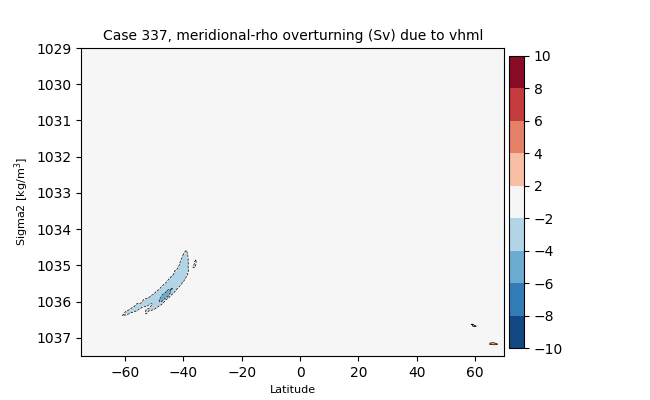

In [20]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_sigma2_global_vhml.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### zrho

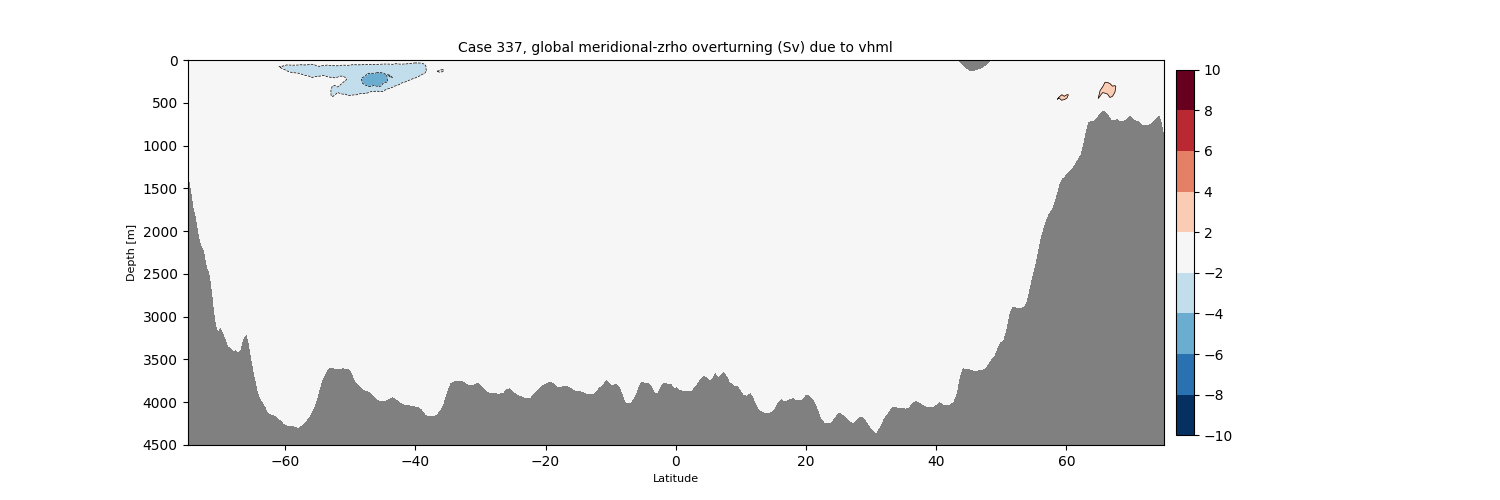

In [21]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_zrho_global_vhml.png')
  for png_file in png_files:
      display(Image(filename=png_file))

### Eddy(GM)-induced Global MOC
#### z

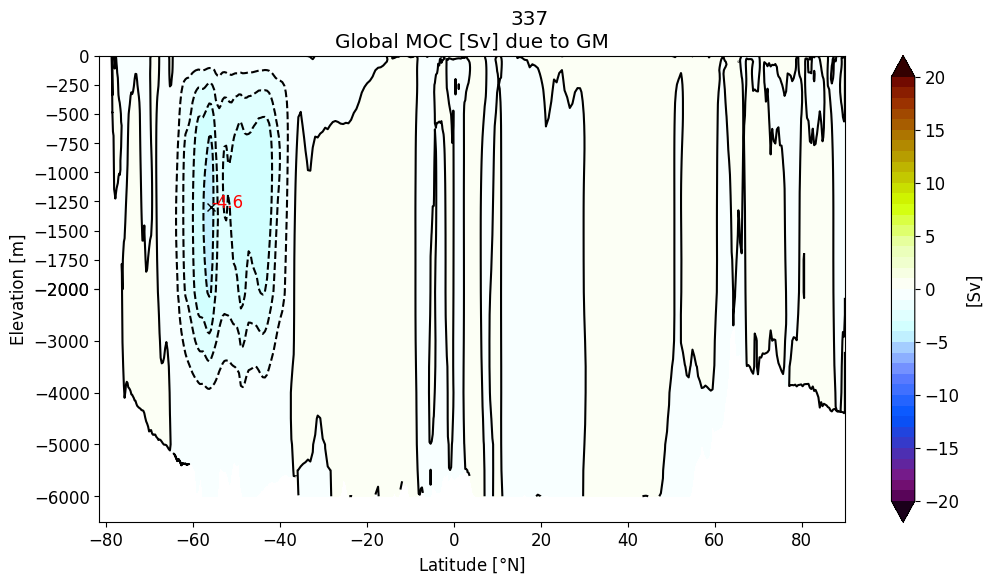

In [22]:
for i in range(pnum):
    # create a ndarray subclass
    class C(np.ndarray): pass
    varName = 'moc_GM'

    psiPlot = np.ma.masked_invalid(ds[i][varName].values)
    tmp = psiPlot[:].filled(0.)
    VHmod = tmp.view(C)
    VHmod.units = 'Sv'

    # Global MOC
    m6plot.setFigureSize([16,9],576,debug=False)
    axis = plt.gca()
    cmap = plt.get_cmap('dunnePM')
    z =  Zmod[i].min(axis=-1) 
    yy = grd[0].geolat_c[:,:].max(axis=-1)+0*z
    ci=m6plot.pmCI(0.,20.,1.)
    plotPsi(yy, z, psiPlot, ci, 'Global MOC [Sv] due to GM')
    plt.xlabel(r'Latitude [$\degree$N]')
    plt.suptitle(label[i])
    findExtrema(yy, z, psiPlot, min_lat=-65., max_lat=-30, mult=-1.)
    plt.gca().invert_yaxis()

#### sigma2

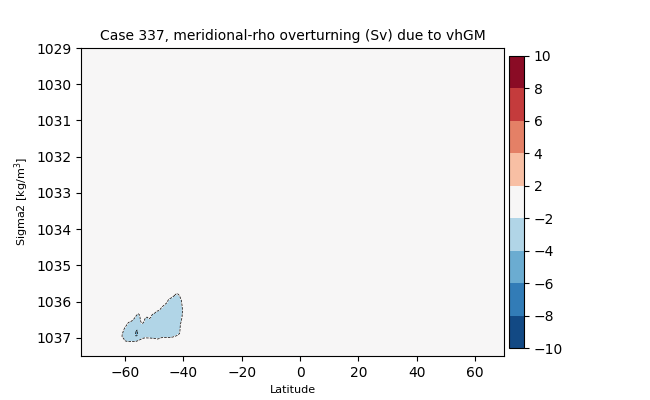

In [23]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_sigma2_global_vhGM.png')
  for png_file in png_files:
      display(Image(filename=png_file))

#### zrho

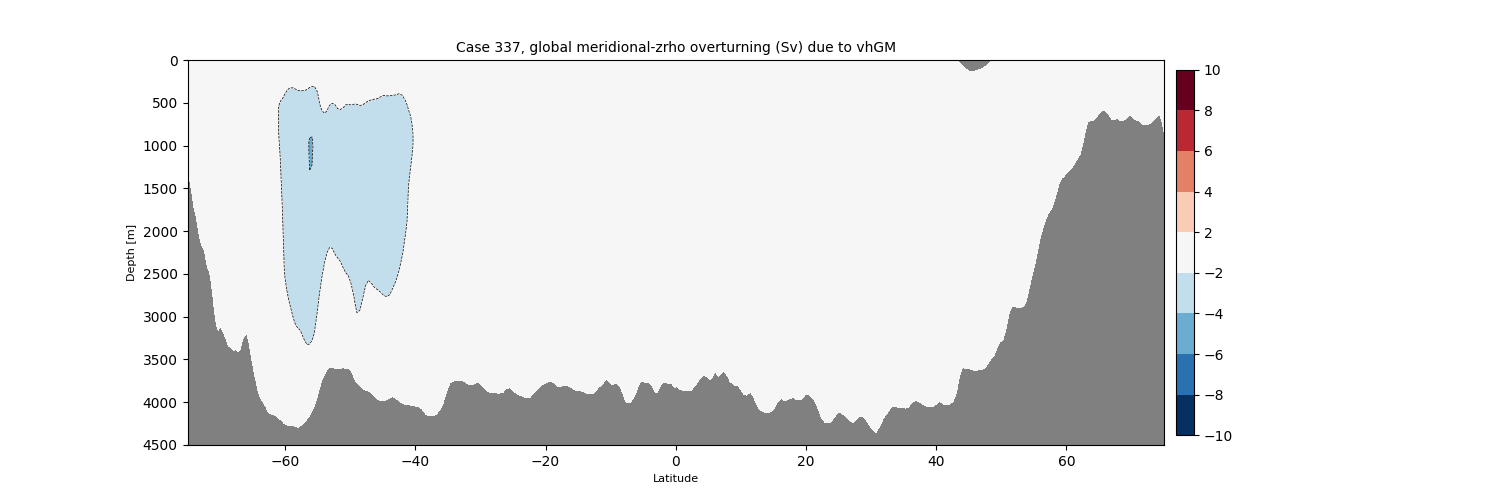

In [24]:
for i in range(len(casename)):
  png_files = glob.glob(ocn_path[i]+'../PNG/MOC/'+casename[i]+'_MOC_zrho_global_vhGM.png')
  for png_file in png_files:
      display(Image(filename=png_file))